# EXERCISE 08: Optimization problems

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


## 08.1

<b> Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian <b>
 $$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$
In which:
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$
$$
V(x) = x^4 - \frac{5}{2}x^2
$$

The expectation value of the Hamiltonian can be computed using an importance sampling technique. This means that, instead of sampling points uniformly, we extract them from the trial wavefunction, allowing us to estimate the integral more accurately and efficiently.

In this first test, I explored different trial values for the ($\mu$,$\sigma$) pairs: when $\mu$ is large and $\sigma$ is small we expect to see very separated narrow peaks, meanwhile when $\mu$ is zero we only expect to see one peak.

#### Metropolis sampling of the wavefunction
In order to do this  I created a modified version of the Metropolis algorithm, that takes 1D steps with an input step length that is chosen so that the acceptance rate approaches 50%, and accepts moves with the usual Metropolis acceptance rate (same function I used in exercise 5).
``` c++
void Metropolis_Step(Random& rnd, double &position,double step_length,double &acc_rate, double mu, double sigma){
	
	double old_pos = position;

	double new_pos=old_pos+step_length*rnd.Rannyu(-1,1);
	double p_old = mu,sigma,old_pos;
	double p_new = psi_T(mu,sigma,new_pos);
	double T_bkw=1.;
	double T_fwd =1.;

	double A=Metropolis_Acceptance(p_new,p_old,T_fwd,T_bkw);
	
	double x = rnd.Rannyu();
	if (x<A){
		acc_rate++;
		position = new_pos;
}
else position = old_pos;
}

I first performed an equilibration of the system to let the acceptance rate stabilize to 50%, and in the following plot we can see that 2000 steps with steplength 2.75 are sufficient to reach the desired result. To compare the point distribution with the trial wavefunction I initially executed the simulation with only 1 block of 100000 steps, that resulted in the histogram below:

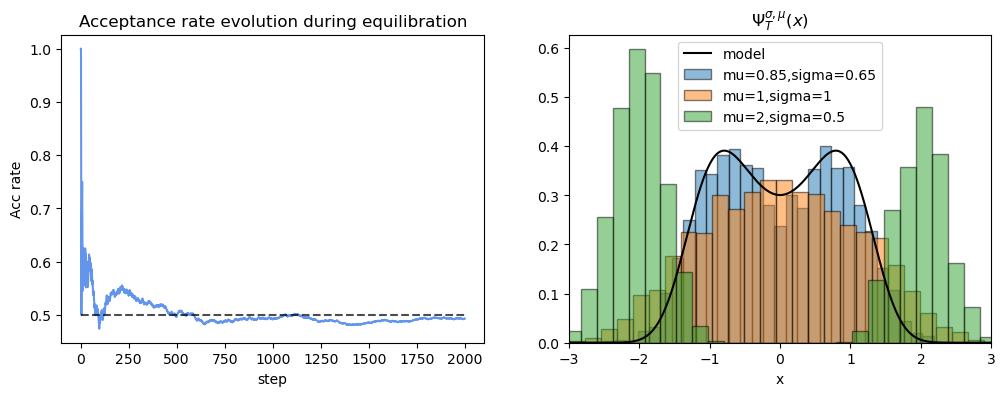

In [39]:

fig,ax = plt.subplots(1,2,figsize=(12,4))

#equilibration
df_acc=pd.read_csv("./OUTPUT/acceptance.csv",sep='\t')
ax[0].plot(df_acc['step'],df_acc['acc_rate'],color='cornflowerblue')
ax[0].hlines(0.5,0,2000,color='black',alpha=0.7,linestyle='dashed')
ax[0].set_title("Acceptance rate evolution during equilibration")
ax[0].set_xlabel("step")
ax[0].set_ylabel ("Acc rate")


#MODEL
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2
hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

#DATA
df= pd.read_csv('./OUTPUT/psi_sampling_correct.csv',sep='\t')
df1= pd.read_csv('./OUTPUT/psi_sampling_ones.csv',sep='\t')
df2= pd.read_csv('./OUTPUT/psi_sampling_peaks.csv',sep='\t')

#plot
ax[1].plot(x,(psi[0])**2,color='black',label='model')
ax[1].hist(df['x'],bins=30,alpha=0.5,edgecolor='black',density=True,label ='mu=0.85,sigma=0.65')
ax[1].hist(df1['x'],bins=30,alpha=0.5,edgecolor='black',density=True,label ='mu=1,sigma=1')
ax[1].hist(df2['x'],bins=30,alpha=0.5,edgecolor='black',density=True,label ='mu=2,sigma=0.5')
ax[1].set_title(r"$\Psi_T^{\sigma,\mu}(x)$")
ax[1].set_xlabel("x")
ax[1].set_xlim((-3,3))
ax[1].legend()


plt.show()

#### Evaluation of $\langle H \rangle$
To evaluate the integral, I used the importance samplng method: first I used the Metropolis I algorithm I showed before to sample a point in the normalized distribution $|\psi |^2$, then I evaluated $\hat{H} \psi$ in that point and incremented the sum variable that keeps track of the integral value. I did this for $10^5$ steps and obtained the final value of the integral, and then repeated for 50 blocks to obtain the final averaged value. In the final plot we can see that when using the theoretical values for $\mu$ and $\sigma$ the simulated values of $\langle H \rangle$ is consistent with the expected value of the ground state energy well within $1\sigma$.
``` c++

	for (int i=1; i<Nsteps; i++){ //steps of RW
		double old_pos = position;
		out<<i<<"\t"<<position<<endl;
		Metropolis_Step(rnd,position,step_length,acc_rate,mu,sigma);
		integral+= Hpsi(mu,sigma,position)/psi_T(mu,sigma,position);	
	}
	
	double ave = integral/double(Nsteps);
	block_ave += ave;
	block_ave2 += ave*ave;
	double err = sqrt((block_ave2/double(j+1)-pow(block_ave/double(j+1),2))/double(j+1));

	outr<<j<<"\t"<<integral/double(Nsteps)<<"\t"<<block_ave/double(j+1)<<"\t"<<err<<endl;

}

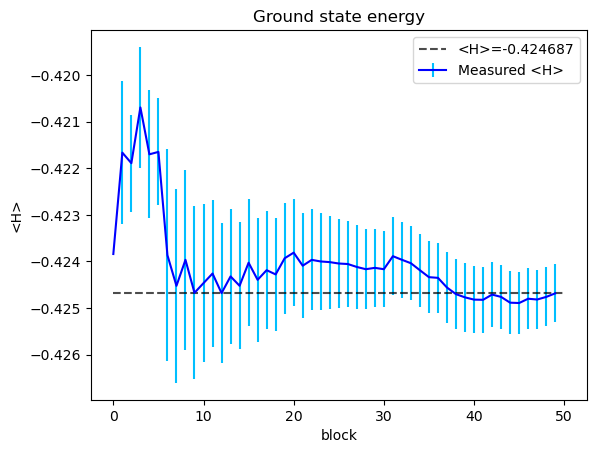

Measured Ground state energy: -0.424687


In [44]:
import matplotlib.pyplot as plt 
import pandas as pd 

df=pd.read_csv('./OUTPUT/ave_correct.csv',sep ='\t')
GS = -0.44
plt.errorbar(df['block'],df['prog_ave'],yerr=df['err'],ecolor='deepskyblue',color='blue',label='Measured <H>')

#plt.hlines(GS,0,50,color='red',linestyle ='dashed',label=f'Model <H>={GS}')
plt.hlines(df['prog_ave'][49],0,50,color ='black',alpha=0.7,linestyle='dashed',label=f'<H>={df['prog_ave'][49]}')
plt.title('Ground state energy')
plt.xlabel('block')
plt.ylabel('<H>')
plt.legend()
plt.show()
print(f'Measured Ground state energy: {df['prog_ave'][49]}')

## 08.2

<b>To find the parameters $\sigma$ and $\mu$ which minimize $\langle {\hat H} \rangle_T$, extend your Variational Monte Carlo code to face the variational optimization problem via a Simulated Annealing (SA) algorithm. <b>

The simulated annealing (SA) algorithm I implemented has the following structure:

- **Annealing step**: An outer *for* loop that progressively lowers the temperature by increasing $\beta$ according to either a scaling law which can be chose by the user between linear (```beta += 0.8```) and non-linear( ```beta *= 1.05```).  
  This choice ensures a slow cooling schedule. At the end of each temperature step, 1000 Metropolis steps are executed.

- **Metropolis step** For each step at a fixed value of $\beta$, new trial values of $\mu$ and $\sigma$ are extracted from Gaussian distributions centered around their previous values. The width of these distributions scales with the temperature, so that at lower $T$ (closer to the minimum) the proposed steps are smaller. Using these proposed parameters, a new value of $\langle H \rangle$ is computed following the same procedure described in Section 8.1.

- If the new value of $\langle H \rangle$ is lower than the previous one, the move is automatically accepted. Otherwise, the acceptance probability is computed using the Boltzmann weight. As a result, when $\beta$ is small (high temperature), the Boltzmann weight is larger and the probability of accepting energetically unfavorable moves increases. This allows the simulation to explore a wider region of parameter space at high $T$ and to gradually converge toward the optimal values as the system cools.

At the end of each block at fixed temperature, I store both the last value of $\langle H \rangle$ obtained in that block and the best result found at that temperature. From the plots below, we observe that the simulation with a non-linear temperature scaling converges much faster to the expected ground-state energy. This is because the system is allowed more effective exploration at high temperatures, enabling it to scan the parameter space more efficiently before cooling down.


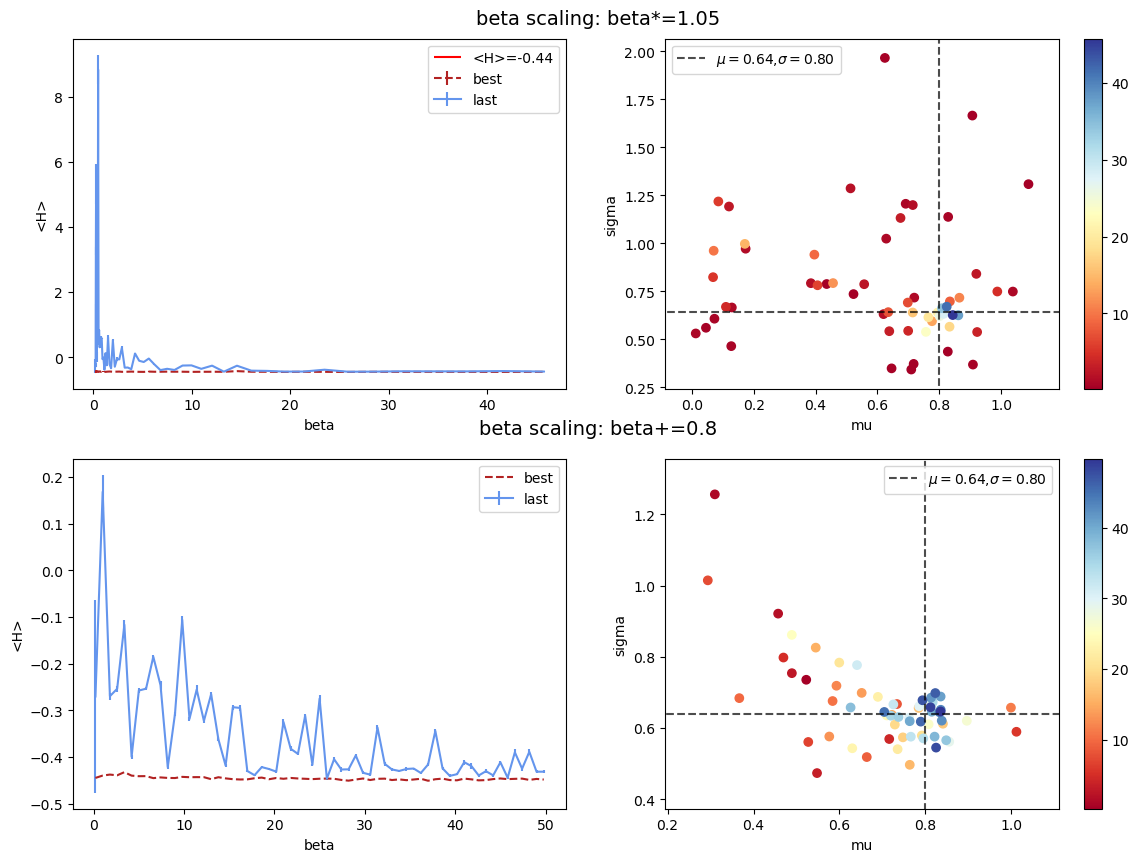

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('./OUTPUT/SAenergy.csv',sep = '\t')
df1 = pd.read_csv ('./OUTPUT/SApars.csv',sep = '\t')

dflin=pd.read_csv('./OUTPUT/SAenergy_linear0.8.csv',sep = '\t')
df1lin = pd.read_csv ('./OUTPUT/SApars_linear0.8.csv',sep = '\t')

fig,ax = plt.subplots(2,2,figsize=(14,10))
fig.text(0.5, 0.9, "beta scaling: beta*=1.05", ha='center', va='center', fontsize=14)

ax[0,0].errorbar(df['beta'],df['meanH_best'],yerr = df['best_err'],label='best',color ='firebrick',linestyle='dashed' )
ax[0,0].errorbar(df['beta'],df['meanH_last'],yerr = df['last_err'],label='last' ,color='cornflowerblue' )

ax[0,0].hlines (-0.44,df['beta'][0],df['beta'][1],color = 'r',label='<H>=-0.44')
ax[0,0].set_xlabel('beta')
ax[0,0].set_ylabel('<H>')

ax[0,0].legend()

sc = ax[0,1].scatter(df1['mu'],df1['sigma'],c=df1['beta'],cmap= 'RdYlBu')
ax[0,1].hlines(0.64,np.min(df1['mu'])-0.2,np.max(df1['mu'])+0.2,color='black',alpha=0.7,linestyle='dashed',label=r'$\mu=0.64$,$\sigma=0.80$')
ax[0,1].vlines(0.8,np.min(df1['sigma'])-0.2,np.max(df1['sigma'])+0.2,color='black',alpha=0.7,linestyle='dashed')
ax[0,1].set_xlabel('mu')
ax[0,1].set_ylabel('sigma')
ax[0,1].set_xlim(np.min(df1['mu'])-0.1,np.max(df1['mu'])+0.1)
ax[0,1].set_ylim(np.min(df1['sigma'])-0.1,np.max(df1['sigma'])+0.1)
ax[0,1].legend()

cbar = fig.colorbar(sc, ax=ax[0,1])

fig.text(0.5, 0.49, "beta scaling: beta+=0.8", ha='center', va='center', fontsize=14)
ax[1,0].errorbar(dflin['beta'],dflin['meanH_best'],label='best',color='firebrick',linestyle='dashed' )
ax[1,0].errorbar(dflin['beta'],dflin['meanH_last'],yerr = dflin['last_err'],label='last',color='cornflowerblue' )

ax[1,0].set_xlabel('beta')
ax[1,0].set_ylabel('<H>')
ax[1,0].legend()


sc = ax[1,1].scatter(df1lin['mu'],df1lin['sigma'],c=df1lin['beta'],cmap= 'RdYlBu')
ax[1,1].hlines(0.64,np.min(df1lin['mu'])-0.2,np.max(df1lin['mu'])+0.2,color='black',alpha=0.7,linestyle='dashed',label=r'$\mu=0.64$,$\sigma=0.80$')
ax[1,1].vlines(0.8,np.min(df1lin['sigma'])-0.2,np.max(df1lin['sigma'])+0.2,color='black',alpha=0.7,linestyle='dashed')
ax[1,1].set_xlabel('mu')
ax[1,1].set_ylabel('sigma')
ax[1,1].set_xlim(np.min(df1lin['mu'])-0.1,np.max(df1lin['mu'])+0.1)
ax[1,1].set_ylim(np.min(df1lin['sigma'])-0.1,np.max(df1lin['sigma'])+0.1)
ax[1,1].legend()

cbar = fig.colorbar(sc, ax=ax[1,1])


we can see that the result is achieved faster with a non linear beta scaling

In [23]:
print (f'Best parameters(non linear scaling):\n mu: {df1['mu'][len(df1)-1]} \n sigma: {df1['sigma'][len(df1)-1]}')
print (f'Best parameters(linear scaling):\n mu: {df1lin['mu'][len(df1lin)-1]} \n sigma: {df1lin['sigma'][len(df1lin)-1]}')

Best parameters(non linear scaling):
 mu: 0.843709 
 sigma: 0.626567
Best parameters(linear scaling):
 mu: 0.835487 
 sigma: 0.646959


#### Ground state energy evaluation
Finally, I used the results of the simulated annealing to get the final estimate of the progressive average of $H$. The non-linear beta scaling gets closer to the theoretical value, however in both cases the measured $\langle H \rangle $ is more than $3\sigma$ above the expectation.

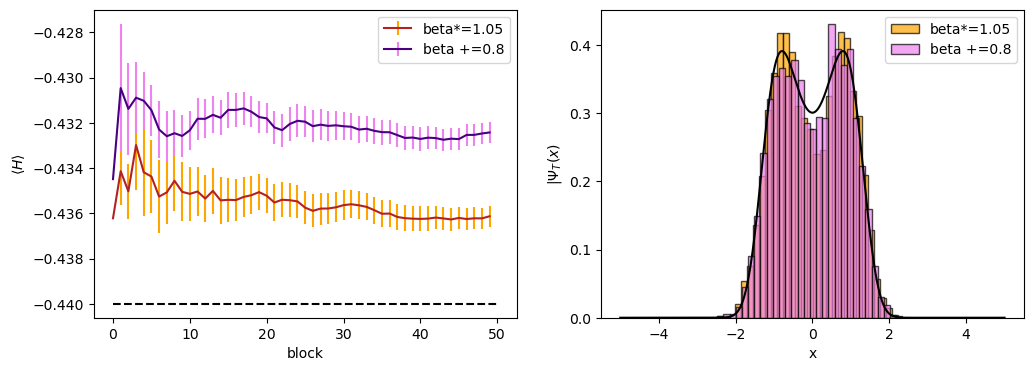

In [2]:
import numpy as np
df = pd.read_csv("./OUTPUT/final_guess_ave.csv",sep = '\t')
df1= pd.read_csv("./OUTPUT/final_sampling.csv",sep = '\t')

dflin = pd.read_csv("./OUTPUT/final_guess_ave_lin.csv",sep = '\t')
df1_lin= pd.read_csv("./OUTPUT/final_sampling_lin.csv",sep = '\t')

fig,ax = plt.subplots(1,2,figsize=(12,4))
ax[0].errorbar(df['block'],df['prog_ave'],yerr=df['err'],label='beta*=1.05',color='firebrick',ecolor='orange')
ax[0].errorbar(dflin['block'],dflin['prog_ave'],yerr=dflin['err'],label='beta +=0.8',color='indigo',ecolor='violet')
ax[0].hlines (-0.44,0,50,color='black',linestyle = 'dashed') 
ax[0].legend()
ax[0].set_xlabel('block')
ax[0].set_ylabel(r'$\langle H \rangle $')
ax[1].hist(df1['x'],bins=30,alpha =0.7, edgecolor='black',density = True,label='beta*=1.05',color='orange')
ax[1].hist(df1_lin['x'],bins=30,alpha =0.7, edgecolor='black',density = True,label='beta +=0.8',color='violet')
ax[1].legend()



#MODEL
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2
hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)
ax[1].plot(x,(psi[0])**2,color='black',label='model')

ax[1].set_ylabel(r"$|\Psi_T(x)$")
ax[1].set_xlabel("x")
plt.show()